# JSL GGUF Vision-Language Models with Spark OCR

This notebook requires Spark OCR 6.4.2.

The examples use GGUF models for inference and execution through `MedicalVisionLLM`. Two models are demonstrated:

- **JSL OCR 1B (`jsl-ocr-gguf-vlm1`)**: extracts OCR text, key-value pairs, and coordinates from documents and images. It can be used for identification and region-aware document understanding tasks.
- **JSL OCR VLM2 (`jsl-ocr-gguf-vlm2`)**: performs OCR, text extraction, key-value extraction, summarization, and question answering, but does not return coordinates.


## Starting Spark Session

Import the required Spark OCR, Spark NLP, PySpark, image processing, JSON, and utility packages before initializing the workflow.

In [1]:
from pyspark.sql import SparkSession
from sparkocr import start
import os

secret = ""
license = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

if license:
    os.environ['SPARK_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path)
spark

Spark version: 3.4.1
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2

:: loading settings :: url = jar:file:/usr/local/lib/python3.11/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp-gpu_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-39345f66-554d-4b04-bff5-36402d1ec871;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp-gpu_2.12;6.4.2 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found software.amazon.ion#ion-java;1.0.2 in central
	found joda-time#joda-time;2.8.1 in central
	found com.amazonaws#jmespath-java;1.12.500 in central
	fou

## SparkOCR Imports

In [2]:
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *
from pyspark.ml import PipelineModel, Pipeline

from sparknlp.annotator import *
from sparknlp.base import *
import sparknlp_jsl
from sparknlp_jsl.annotator import *

from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.ml import PipelineModel, Pipeline
from pyspark.ml.feature import SQLTransformer
import pkg_resources

import numpy as np
from PIL import Image
import io
import re
import json
from pprint import pprint

/tmp/ipykernel_44953/3580936006.py:15: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


## JSL-OCR 1B GGUF

In [3]:
from sparkocr.transformers.medical_vision_llm import MedicalVisionLLM

jsl_ocr_1B = MedicalVisionLLM.pretrained("jsl-ocr-gguf-vlm1", "en", "clinical/ocr") \
  .setInputCols(["caption_document", "image_assembler"]) \
  .setOutputCol("completions") \
  .setNGpuLayers(99) \
  .setNCtx(32768) \
  .setNParallel(1) \
  .setNBatch(2048) \
  .setNUbatch(1024) \
  .setNPredict(1024) \
  .setTemperature(0.01) \
  .setTopK(1) \
  .setTopP(1.0) \
  .setRepeatPenalty(1.03) \
  .setRepeatLastN(256) \
  .setStopStrings(["<\uff5chy_Assistant\uff5c>", "<\uff5chy_place\u2581holder\u2581no\u25812\uff5c>"]) \
  .setMinKeep(0) \
  .setNProbs(0) \
  .setOutputCol("completions") \
  .setBatchSize(1) \
  .setDisableLog(False)

jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB
jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB
Download done! Loading the resource.
Extracted 'libjllama.so' to '/content/tmp/libjllama.so'


ggml_cuda_init: found 1 CUDA devices (Total VRAM: 45498 MiB):
  Device 0: NVIDIA A40, compute capability 8.6, VMM: yes, VRAM: 45498 MiB


## OCR Task with Detection

Use the JSL OCR 1B model to detect and recognize text in the image, returning text with coordinates in a formatted output.

In [4]:
ocr_prompt = "Detect and recognize text in the image, and output the text coordinates in a formatted manner."

In [5]:
path = "./deid-and-obfuscation/source_pdfs/Easy/PDF_Deid_Deidentification_0.pdf"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(ocr_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

## Image Conversion for GGUF Inference

`PdfToImage`, `BinaryToImage`, or `DicomToImageV3` can be used to convert source documents or images before inference. `ImageSchemaConverter` converts images into the format required for GGUF inference with `MedicalVisionLLM`.

Convert the image schema back to `ImageSchemaConversion.INTERNAL` when rendering images or using downstream image tasks, and use `ImageSchemaConversion.ASSEMBLER` for model inference. Set `setCompressImage(True)` when working with `MedicalVisionLLM`. The same conversion flow applies when working with images or DICOM files.

In [6]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setKeepInput(False) \
    .setImageType(ImageType.TYPE_BYTE_GRAY) \
    .setSplittingStategy(SplittingStrategy.FIXED_SIZE_OF_PARTITION) \
    .setImageDimsCol("image_dims") \
    .setCompressImage(True)
    
caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema(ImageSchemaConversion.ASSEMBLER) \
    .setKeepInput(False)

coordinate_extract = DocumentCoordinatesToText() \
    .setInputCol("completions") \
    .setImageDimsCol("image_dims") \
    .setOutputCol("text") \
    .setPageMatrixCol("positions") \
    .setRegionCol("regions")

schema_converter_internal = ImageSchemaConverter() \
    .setInputCol("image_assembler") \
    .setOutputCol("image") \
    .setOutputSchema(ImageSchemaConversion.INTERNAL) \
    .setKeepInput(False)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("regions") \
    .setOutputCol("image_with_regions") \
    .setPatchImages(False) \
    .setFontName("Courier") \
    .setRectColor(Color.green) \
    .setDisplayMetadata(True)

pipeline = PipelineModel(stages=[
    pdf_to_image,
    caption_assembler,
    schema_converter_assembler,
    jsl_ocr_1B,
    coordinate_extract,
    schema_converter_internal,
    draw_regions
])

In [7]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'completions',
 'text',
 'regions',
 'positions',
 'image',
 'image_with_regions',
 'exception']

In [8]:
result.select(col("text").alias("Ocr Text")).show(10, False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


    Image #0:
    Origin: file:/workspace/visual-nlp-workshop/jupyter/deid-and-obfuscation/source_pdfs/Easy/PDF_Deid_Deidentification_0.pdf
    Resolution: 0 dpi
    Width: 2480 px
    Height: 3507 px
    Mode: 10
    Number of channels: 1


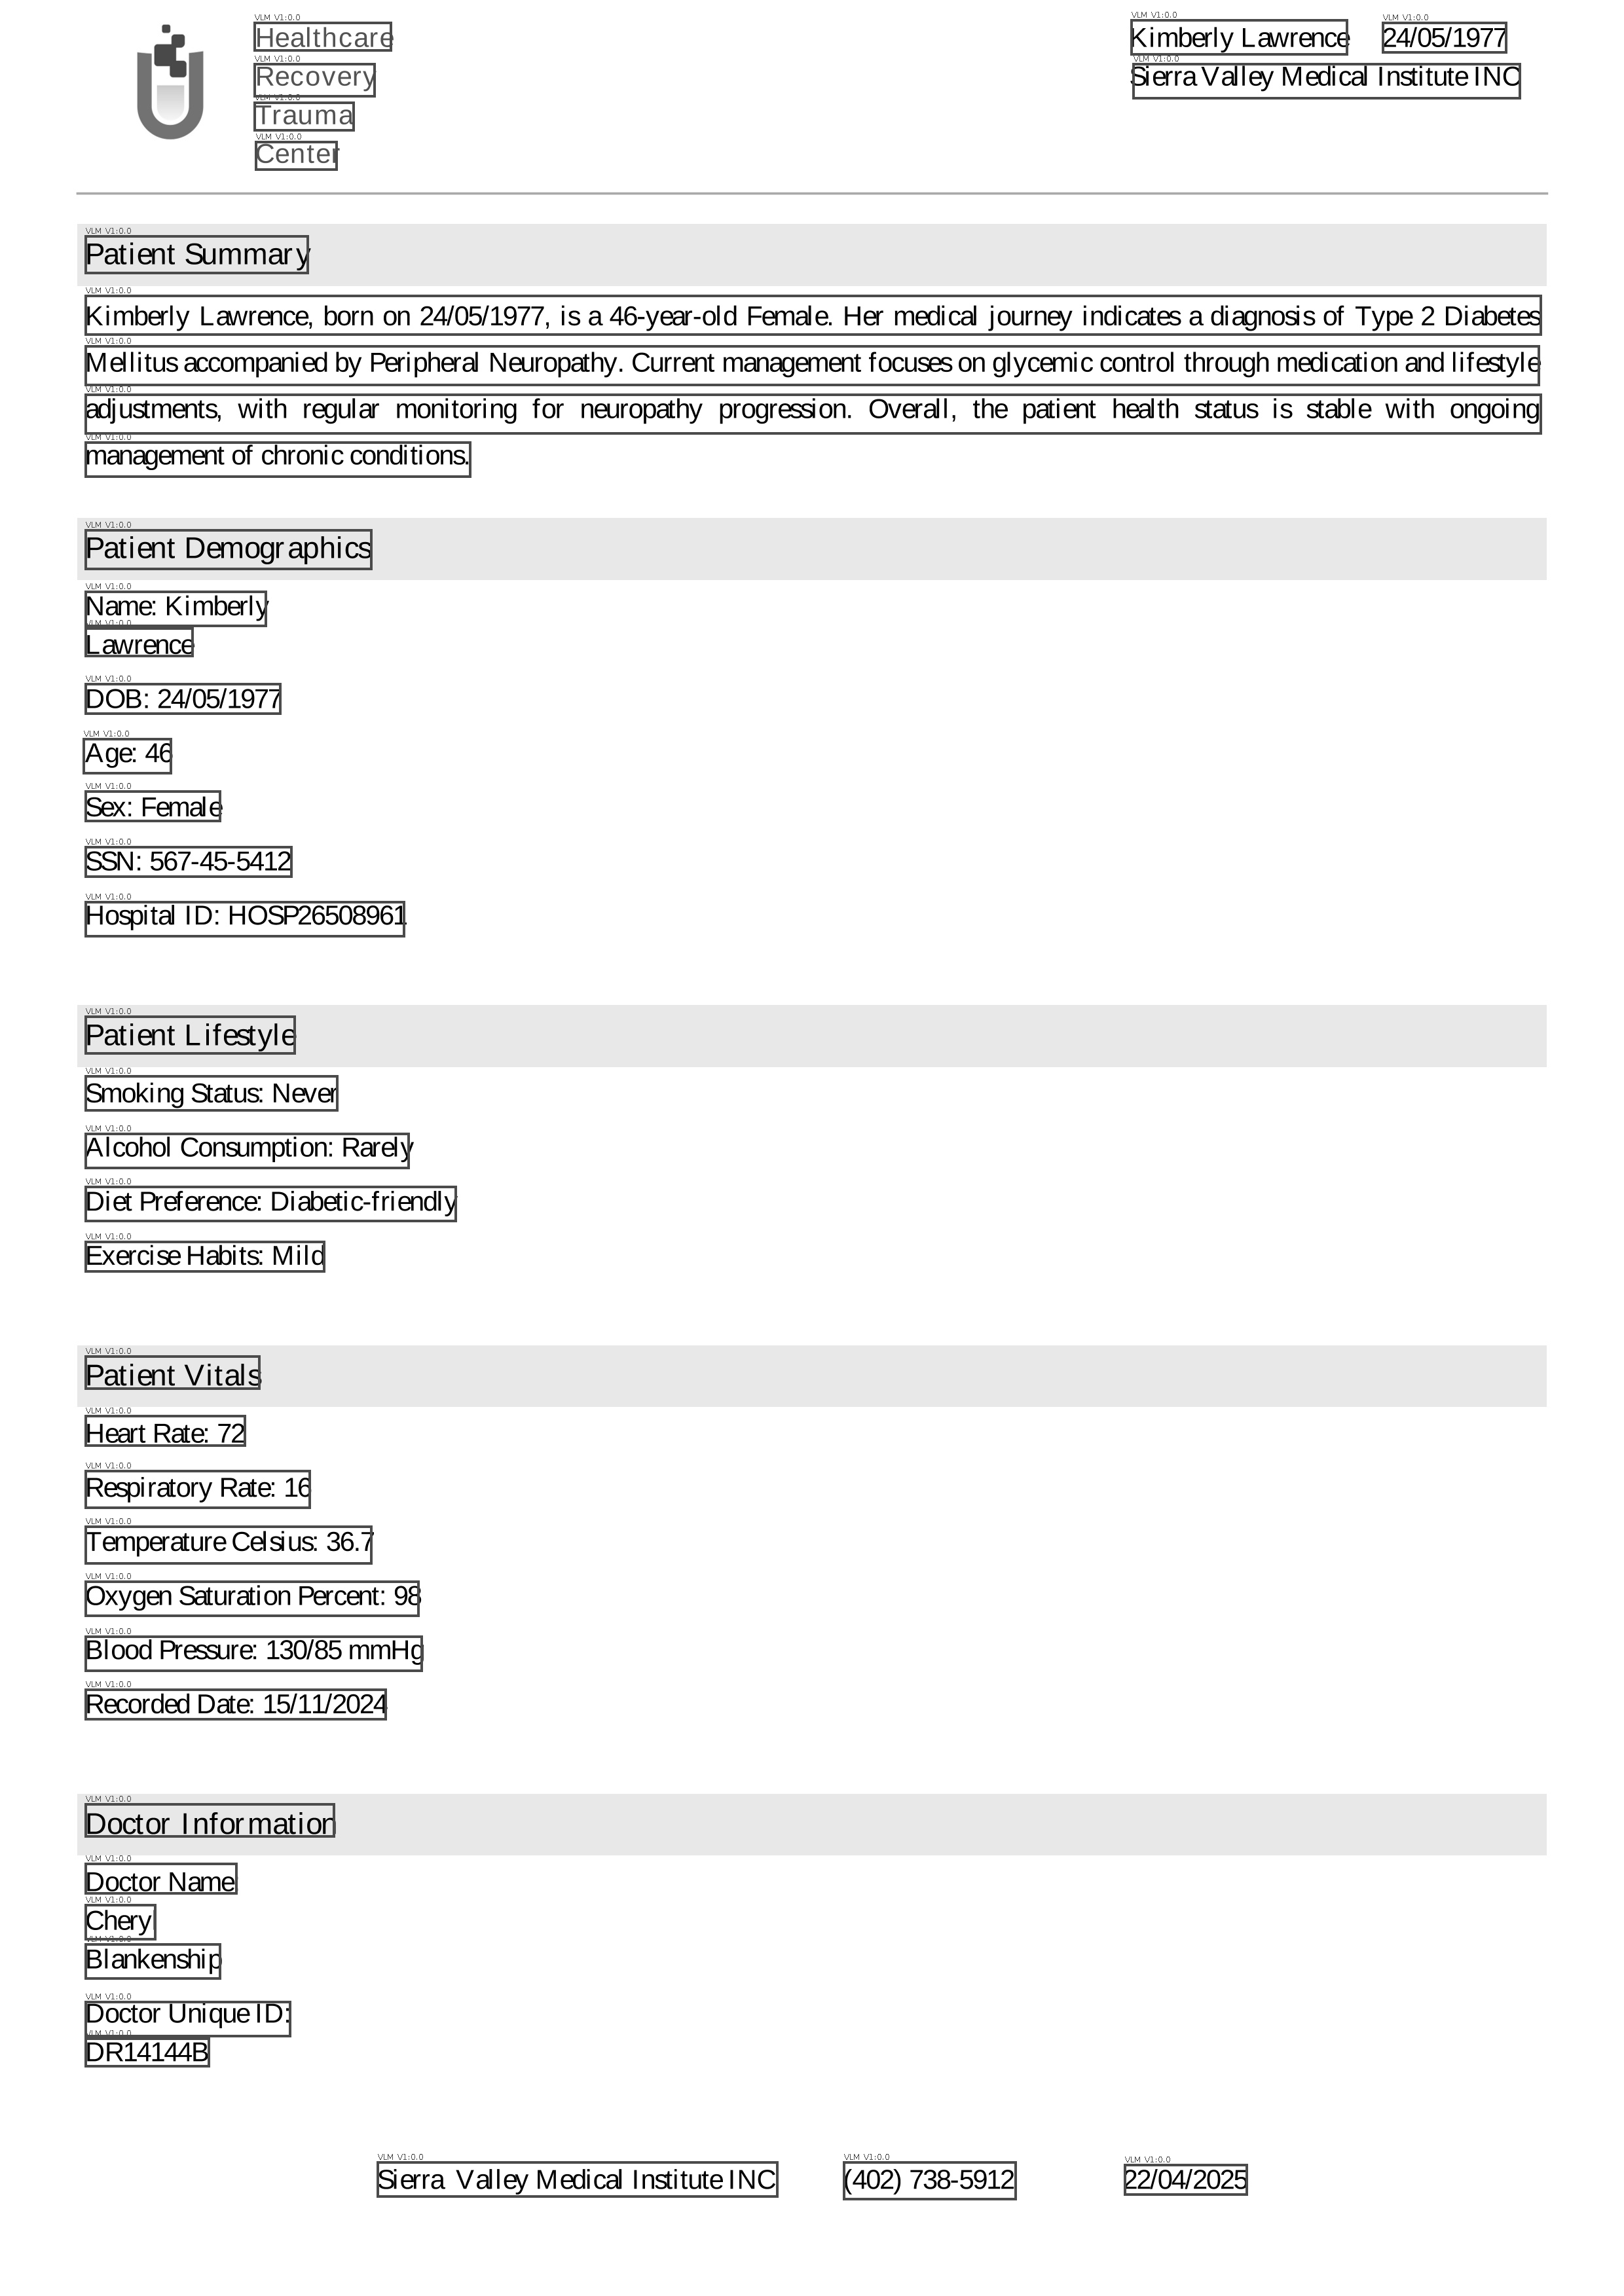

In [9]:
display_images(result, "image_with_regions", limit=1, width=400, show_meta=True)

## Key-Value Extraction

Ask the model to extract all key-value pairs from the document image and return the results as JSON.

In [10]:
key_value_prompt = "Extract all key-value pairs from the image and return the results in JSON format."

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(key_value_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [11]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setKeepInput(False) \
    .setImageType(ImageType.TYPE_BYTE_GRAY) \
    .setSplittingStategy(SplittingStrategy.FIXED_SIZE_OF_PARTITION) \
    .setImageDimsCol("image_dims") \
    .setCompressImage(True)
    
caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema(ImageSchemaConversion.ASSEMBLER) \
    .setKeepInput(False)

pipeline = PipelineModel(stages=[
    pdf_to_image,
    caption_assembler,
    schema_converter_assembler,
    jsl_ocr_1B
])

## Run on the First PDF Page

For this example, transform the input and keep only the first page of the PDF.

In [12]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [13]:
kv_result = result.select(col("completions.result").alias("JSON Result")).collect()[0].asDict()["JSON Result"][0]

clean = re.sub(r'^\s*```(?:json)?\s*|\s*```\s*$', '', kv_result.strip(), flags=re.I)

kv_dict = json.loads(clean)

pprint(kv_dict)

('```json\n'
 '{\n'
 '    "Patient Summary": {\n'
 '        "Name": "Kimberly Lawrence",\n'
 '        "Born on 24/05/1977": "24/05/1977",\n'
 '        "Sex": "Female",\n'
 '        "SSN": "567-45-5412",\n'
 '        "Hospital ID": "HOSP26508961"\n'
 '    },\n'
 '    "Patient Demographics": {\n'
 '        "Name": "Kimberly Lawrence",\n'
 '        "DOB": "24/05/1977",\n'
 '        "Age": "46",\n'
 '        "Sex": "Female",\n'
 '        "SSN": "567-45-5412",\n'
 '        "Hospital ID": "HOSP26508961"\n'
 '    },\n'
 '    "Patient Lifestyle": {\n'
 '        "Smoking Status": "Never",\n'
 '        "Alcohol Consumption": "Rarely",\n'
 '        "Diet Preference": "Diabetic-friendly",\n'
 '        "Exercise Habits": "Mild"\n'
 '    },\n'
 '    "Patient Vitals": {\n'
 '        "Heart Rate": "72",\n'
 '        "Respiratory Rate": "16",\n'
 '        "Temperature Celsius": "36.7",\n'
 '        "Oxygen Saturation Percent": "98",\n'
 '        "Blood Pressure": "130/85 mmHg",\n'
 '        "Recorded D

## Targeted Key-Value Extraction

Provide a specific list of fields to extract from the image and return only those values in JSON format.

In [14]:
target = [
    "Patient Name",
    "Hospital ID",
    "Doctor Name",
    "Doctor Unique ID",
    "SSN"
]

targeted_key_value_prompt = f"Extract the following fields from the image: {target}, and return the results in JSON format."

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(targeted_key_value_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [15]:
result = pipeline.transform(df).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [16]:
targeted_kv_result = result.select(col("completions.result").alias("JSON Result")).collect()[0].asDict()["JSON Result"][0]

clean = re.sub(r'^\s*```(?:json)?\s*|\s*```\s*$', '', targeted_kv_result.strip(), flags=re.I)

kv_dict = json.loads(clean)

pprint(kv_dict)

('```json\n'
 '{\n'
 '    "Patient Name": "Kimberly Lawrence",\n'
 '    "Hospital ID": "Sierra Valley Medical Institute INC",\n'
 '    "Doctor Name": "Kimberly Lawrence",\n'
 '    "Doctor Unique ID": "402 738-5912",\n'
 '    "SSN": "24/05/1977"\n'
 '}\n'
 '```')


## JSL-OCR VLM2

## JSL OCR VLM2 Model

The JSL OCR VLM2 model can perform OCR and JSON extraction tasks, but it does not return coordinates.

In [17]:
jsl_ocr = MedicalVisionLLM.pretrained("jsl-ocr-gguf-vlm2", "en", "clinical/ocr") \
  .setInputCols(["caption_document", "image_assembler"]) \
  .setOutputCol("completions") \
  .setNGpuLayers(99) \
  .setNCtx(32768) \
  .setNParallel(1) \
  .setNBatch(2048) \
  .setNUbatch(1024) \
  .setNPredict(1024) \
  .setTemperature(0.01) \
  .setTopK(1) \
  .setTopP(1.0) \
  .setRepeatPenalty(1.03) \
  .setRepeatLastN(256) \
  .setStopStrings(["<\uff5chy_Assistant\uff5c>", "<\uff5chy_place\u2581holder\u2581no\u25812\uff5c>"]) \
  .setMinKeep(0) \
  .setNProbs(0) \
  .setOutputCol("completions") \
  .setBatchSize(1) \
  .setDisableLog(False)

jsl-ocr-gguf-vlm2 download started this may take some time.
Approximate size to download 1.3 GB


jsl-ocr-gguf-vlm2 download started this may take some time.
Approximate size to download 1.3 GB
Download done! Loading the resource.


In [18]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setKeepInput(False) \
    .setImageType(ImageType.TYPE_BYTE_GRAY) \
    .setSplittingStategy(SplittingStrategy.FIXED_SIZE_OF_PARTITION) \
    .setImageDimsCol("image_dims") \
    .setCompressImage(True)
    
caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema(ImageSchemaConversion.ASSEMBLER) \
    .setKeepInput(False)

pipeline = PipelineModel(stages=[
    pdf_to_image,
    caption_assembler,
    schema_converter_assembler,
    jsl_ocr_1B
])

## OCR

Use the JSL OCR VLM2 model to extract all text from the image.

In [19]:
ocr_prompt = "Extract all text from the image."

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(ocr_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [20]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [21]:
result.select(col("completions.result").alias("Ocr Text")).show(10, False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Key-Value Extraction

Ask the JSL OCR VLM2 model to extract all key-value pairs from the image and return them as JSON.

In [22]:
key_value_prompt = "Extract all key-value pairs from the image and return the results in JSON format."

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(key_value_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [23]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [24]:
kv_result = result.select(col("completions.result").alias("JSON Result")).collect()[0].asDict()["JSON Result"][0]

clean = re.sub(r'^\s*```(?:json)?\s*|\s*```\s*$', '', kv_result.strip(), flags=re.I)

kv_dict = json.loads(clean)

pprint(kv_dict)

('```json\n'
 '{\n'
 '    "Patient Summary": {\n'
 '        "Name": "Kimberly Lawrence",\n'
 '        "Born on 24/05/1977": "24/05/1977",\n'
 '        "Sex": "Female",\n'
 '        "SSN": "567-45-5412",\n'
 '        "Hospital ID": "HOSP26508961"\n'
 '    },\n'
 '    "Patient Demographics": {\n'
 '        "Name": "Kimberly Lawrence",\n'
 '        "DOB": "24/05/1977",\n'
 '        "Age": "46",\n'
 '        "Sex": "Female",\n'
 '        "SSN": "567-45-5412",\n'
 '        "Hospital ID": "HOSP26508961"\n'
 '    },\n'
 '    "Patient Lifestyle": {\n'
 '        "Smoking Status": "Never",\n'
 '        "Alcohol Consumption": "Rarely",\n'
 '        "Diet Preference": "Diabetic-friendly",\n'
 '        "Exercise Habits": "Mild"\n'
 '    },\n'
 '    "Patient Vitals": {\n'
 '        "Heart Rate": "72",\n'
 '        "Respiratory Rate": "16",\n'
 '        "Temperature Celsius": "36.7",\n'
 '        "Oxygen Saturation Percent": "98",\n'
 '        "Blood Pressure": "130/85 mmHg",\n'
 '        "Recorded D

## Targeted Key-Value Extraction

Provide the JSL OCR VLM2 model with a target list of fields to extract from the image and return the values as JSON.

In [25]:
target = [
    "Patient Name",
    "Hospital ID",
    "Doctor Name",
    "Doctor Unique ID",
    "SSN"
]

targeted_key_value_prompt = f"Extract the following fields from the image: {target}, and return the results in JSON format."

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(targeted_key_value_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [26]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [27]:
targeted_kv_result = result.select(col("completions.result").alias("JSON Result")).collect()[0].asDict()["JSON Result"][0]

clean = re.sub(r'^\s*```(?:json)?\s*|\s*```\s*$', '', targeted_kv_result.strip(), flags=re.I)

kv_dict = json.loads(clean)

pprint(kv_dict)

('```json\n'
 '{\n'
 '    "Patient Name": "Kimberly Lawrence",\n'
 '    "Hospital ID": "HOSP26508961",\n'
 '    "Doctor Name": "Cheryl",\n'
 '    "Doctor Unique ID": "DR14144B",\n'
 '    "SSN": "567-45-5412"\n'
 '}\n'
 '```')


## Summary Generation

Generate a concise summary of the document with the JSL OCR VLM2 model.

In [28]:
summary_prompt = "Summarize the document."

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(summary_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [29]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [30]:
result.select(col("completions.result").alias("Summary")).show(10, False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Summary                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
+---------------------------------------------------------------------------------------------

## Question Answering

Ask a document-specific question and return the model's answer from the image content.

In [31]:
qa_prompt = "What is the patient's main diagnosis?"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(qa_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [32]:
result = pipeline.transform(df).filter(F.col("pagenum") == 0).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'exception',
 'pagenum',
 'documentnum',
 'image_dims',
 'caption_document',
 'image_assembler',
 'completions']

In [33]:
result.select(col("caption").alias("Question"), col("completions.result").alias("Answer")).show(10, False)

+-------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Question                             |Answer                                                                                                                                                                                                                                                                                                                                                                  |
+-------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------